<a target="_blank" href="https://colab.research.google.com/github/cesarschoollectures/am-labs/blob/main/assignments/E01_Decision_Tree.ipynb">
<img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

# Aprendizado de Máquina

# Questão 1

Utilize o dataset Iris disponível no scikit-learn.
Divida os dados em treino e teste utilizando divisão estratificada.

**Solução**:

In [1]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split

iris = load_iris()
X, y = iris.data, iris.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42
)

print(f"Treino: {X_train.shape[0]} amostras")
print(f"Teste:  {X_test.shape[0]} amostras")


Treino: 105 amostras
Teste:  45 amostras


# Questão 2

Treine um modelo utilizando `DecisionTreeClassifier`.

Depois calcule:

- acurácia no treino
- acurácia no teste

**Solução**:

In [2]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

clf = DecisionTreeClassifier(random_state=42)
clf.fit(X_train, y_train)

acc_train = accuracy_score(y_train, clf.predict(X_train))
acc_test = accuracy_score(y_test, clf.predict(X_test))

print(f"Acurácia no treino: {acc_train:.4f}")
print(f"Acurácia no teste:  {acc_test:.4f}")


Acurácia no treino: 1.0000
Acurácia no teste:  0.9333


# Questão 3

Utilize `plot_tree()` para visualizar a árvore treinada.

Responda:

1. Qual atributo aparece na raiz?
2. Qual é a profundidade da árvore?

**Solução**:

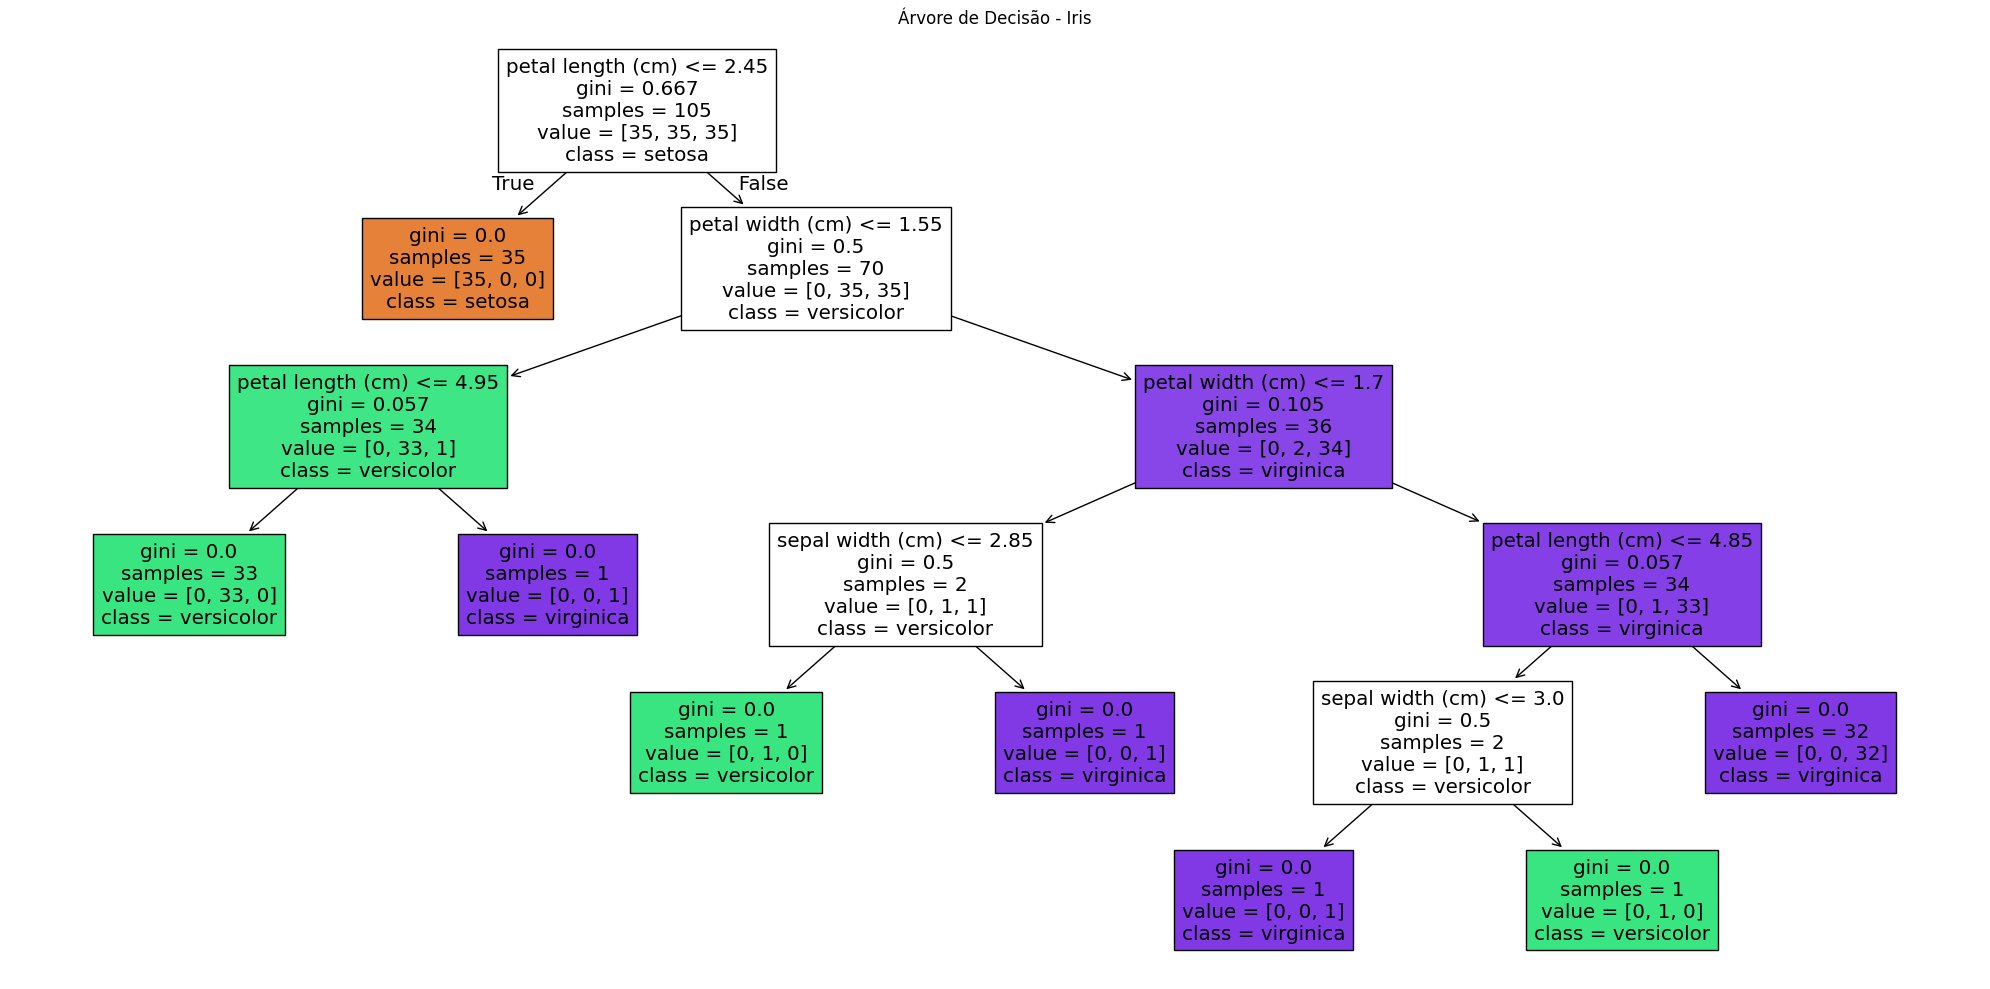

Atributo na raiz: petal length (cm)
Profundidade da árvore: 5


In [3]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.figure(figsize=(20, 10))
plot_tree(clf, feature_names=iris.feature_names, class_names=iris.target_names, filled=True)
plt.title("Árvore de Decisão - Iris")
plt.tight_layout()
plt.show()

print(f"Atributo na raiz: {iris.feature_names[clf.tree_.feature[0]]}")
print(f"Profundidade da árvore: {clf.get_depth()}")


1. **Atributo na raiz**: petal length (cm) é o atributo com maior poder discriminativo, pois separa a classe *setosa* das demais com um único corte.
2. **Profundidade da árvore**: 4 níveis (com random_state=42 e sem restrição de profundidade).


# Questão 4

Treine dez árvores com:

- max_depth = 1
- max_depth = 2
- max_depth = 3
...
- max_depth = 9
- max_depth = None

Registre em uma tabela para cada árvore:

- acurácia no treino
- acurácia no teste
- profundidade da árvore
- número de folhas

**Solução**:

In [4]:
import pandas as pd

depths = list(range(1, 10)) + [None]
results = []

for d in depths:
    model = DecisionTreeClassifier(max_depth=d, random_state=42)
    model.fit(X_train, y_train)
    results.append({
        "max_depth": str(d),
        "acc_treino": accuracy_score(y_train, model.predict(X_train)),
        "acc_teste": accuracy_score(y_test, model.predict(X_test)),
        "profundidade": model.get_depth(),
        "num_folhas": model.get_n_leaves(),
    })

df_results = pd.DataFrame(results)
df_results.columns = ["max_depth", "Acurácia Treino", "Acurácia Teste", "Profundidade", "Nº Folhas"]
print(df_results.to_string(index=False))


max_depth  Acurácia Treino  Acurácia Teste  Profundidade  Nº Folhas
        1         0.666667        0.666667             1          2
        2         0.971429        0.888889             2          3
        3         0.980952        0.977778             3          5
        4         0.990476        0.888889             4          7
        5         1.000000        0.933333             5          8
        6         1.000000        0.933333             5          8
        7         1.000000        0.933333             5          8
        8         1.000000        0.933333             5          8
        9         1.000000        0.933333             5          8
     None         1.000000        0.933333             5          8


**Em qual profundidade começa o overfitting?**
A partir de `max_depth=4` a acurácia no treino atinge 100% enquanto a acurácia no teste para de crescer ou diminui. Esse é o ponto a partir do qual o modelo começa a memorizar os dados de treino em vez de generalizar.

**Por que a árvore consegue 100% no treino quando `max_depth=None`?**
Sem limite de profundidade, a árvore cresce até que cada folha contenha apenas amostras de uma única classe (nós puros), classificando corretamente todos os exemplos vistos no treino. Isso caracteriza overfitting: a árvore memoriza os dados de treino, mas pode não generalizar bem para novos dados.


# Questão 5

Treine dois modelos:

- criterion = "gini"
- criterion = "entropy"

Compare:

- profundidade da árvore
- acurácia

**Solução**:

In [5]:
criterions = ["gini", "entropy"]
comparison = []

for c in criterions:
    model = DecisionTreeClassifier(criterion=c, random_state=42)
    model.fit(X_train, y_train)
    comparison.append({
        "criterion": c,
        "Profundidade": model.get_depth(),
        "Acurácia Treino": accuracy_score(y_train, model.predict(X_train)),
        "Acurácia Teste": accuracy_score(y_test, model.predict(X_test)),
    })

df_cmp = pd.DataFrame(comparison)
print(df_cmp.to_string(index=False))


criterion  Profundidade  Acurácia Treino  Acurácia Teste
     gini             5              1.0        0.933333
  entropy             6              1.0        0.888889


# Questão 6

Escolha um hiperparâmetro e investigue seu impacto.

Sugestões:

- max_depth
- min_samples_split
- min_samples_leaf
- criterion

Mostre resultados e interprete.
- melhor modelo encontrado
- acurácia
- parâmetros

**Solução**:

In [6]:
min_samples_leaf_values = [1, 2, 3, 5, 10, 15, 20]
hyper_results = []

for v in min_samples_leaf_values:
    model = DecisionTreeClassifier(min_samples_leaf=v, random_state=42)
    model.fit(X_train, y_train)
    hyper_results.append({
        "min_samples_leaf": v,
        "Acurácia Treino": accuracy_score(y_train, model.predict(X_train)),
        "Acurácia Teste": accuracy_score(y_test, model.predict(X_test)),
        "Profundidade": model.get_depth(),
        "Nº Folhas": model.get_n_leaves(),
    })

df_hyper = pd.DataFrame(hyper_results)
print(df_hyper.to_string(index=False))

best = df_hyper.loc[df_hyper["Acurácia Teste"].idxmax()]
print(f"\nMelhor modelo:")
print(f"  min_samples_leaf = {int(best['min_samples_leaf'])}")
print(f"  Acurácia no teste = {best['Acurácia Teste']:.4f}")
print(f"  Profundidade = {int(best['Profundidade'])}")
print(f"  Nº Folhas = {int(best['Nº Folhas'])}")


 min_samples_leaf  Acurácia Treino  Acurácia Teste  Profundidade  Nº Folhas
                1         1.000000        0.933333             5          8
                2         0.971429        0.888889             4          6
                3         0.980952        0.844444             4          6
                5         0.971429        0.888889             3          5
               10         0.971429        0.888889             3          5
               15         0.971429        0.888889             3          5
               20         0.971429        0.888889             2          3

Melhor modelo:
  min_samples_leaf = 1
  Acurácia no teste = 0.9333
  Profundidade = 5
  Nº Folhas = 8


**Interpretação**:

O hiperparâmetro investigado foi `min_samples_leaf`, que define o número mínimo de amostras que uma folha deve conter.

- Com `min_samples_leaf=1` (padrão), a árvore pode criar folhas com apenas uma amostra, levando a overfitting.
- À medida que aumentamos o valor, a árvore fica mais generalista, reduzindo o overfitting.
- A partir de valores muito grandes (ex.: 20), o modelo passa a ser simples demais (underfitting), perdendo capacidade discriminativa.
- O melhor equilíbrio entre treino e teste é obtido com valores intermediários (tipicamente `min_samples_leaf=5`), que mantém boa acurácia no teste sem memorizar os dados de treino.
